【StarVLA / Qwen3-VL-OFT-LIBERO-4in1】VLA 机器人动作推理服务
====

> **StarVLA · 通用 VLA 研究平台**：基于 Qwen3-VL-4B-Instruct 视觉语言模型，
> 结合 MLP 动作回归头（QwenOFT 框架），实现从图像 + 自然语言指令到 7-DoF 机器人动作的端到端推理。
> MIT 开源许可证，完全开源非门控。
> P1.gpu.medium（40GB）完整加载 BF16 权重。

## 一、项目简介

### 1.1 官方介绍

[StarVLA](https://github.com/starVLA/starVLA) 是一个用于通用机器人 VLA（Vision-Language-Action）研究的开源平台。
它提供统一的框架来训练和评估多种 VLA 架构，支持多种 VLM 后端和动作头。

**QwenOFT**（Qwen3-VL + MLP OFT）是 StarVLA 支持的推理框架之一：
- VLM 后端：Qwen3-VL-4B-Instruct（Qwen3-VL 4B 对话版）
- 动作头：`L1RegressionActionHead`（MLPResNet，2 个残差块）
- 推理方式：向 VLM 末尾注入 Action Token 🔍 → 提取 hidden state → MLP 回归 7-DoF 动作
- 训练数据集：LIBERO 4in1（4 个 LIBERO 任务的联合训练）

### 1.2 本项目信息

| 项目属性 | 内容 |
|---------|------|
| **实现类型** | ① 推理服务（Gradio WebUI） |
| **模型名称** | StarVLA / Qwen3-VL-OFT-LIBERO-4in1 |
| **VLM 基座** | Qwen3-VL-4B-Instruct |
| **动作架构** | QwenOFT（Qwen3-VL + MLPResNet 回归头） |
| **动作空间** | 7-DoF（x, y, z, roll, pitch, yaw, gripper） |
| **动作范围** | 归一化至 [-1, 1] |
| **推理方式** | 单次前向传播（非自回归） |
| **精度** | BF16（~10GB VRAM） |
| **上下文长度** | 约 1100 tokens（图像 ~1024 + 指令 ~20） |
| **许可证** | MIT（可商用） |

### 1.3 关键架构特点

- **非自回归推理**：无需逐个 token 生成，一次前向传播即可得到全部动作序列
- **Action Token 机制**：在 VLM 序列末尾注入 "🔍" token，提取其 hidden state 作为动作特征
- **MLP 回归头**：2 层 MLPResNet，输入维度 = VLM hidden_size → 输出 7-DoF 动作
- **Action Horizon**：单次推理输出 T 步动作轨迹（由训练配置决定，通常为 8 步）
- **数据集统计归一化**：输出动作经 dataset_statistics.json 的 mean/std 归一化

## 二、官方链接

| 类别 | 链接 |
|------|------|
| 🐙 GitHub | https://github.com/starVLA/starVLA |
| 🏠 HuggingFace（StarVLA） | https://huggingface.co/StarVLA |
| 🤗 Qwen3-VL-4B-Instruct | https://huggingface.co/Qwen/Qwen3-VL-4B-Instruct |
| 📄 VLM 基座论文 | https://arxiv.org/abs/2505.03730 |
| 🇨🇳 hf-mirror 镜像 | https://hf-mirror.com/StarVLA |

## 三、算力推荐

| 配置等级 | 推荐 GPU | 显存要求 | 说明 |
|---------|----------|---------|------|
| **最低配置** | P1.gpu.medium（40GB） | ≥ 16 GB | BF16 推理 ~10GB VRAM，40GB 充裕 |
| **推荐配置** | P1.2xlarge（1×A100-40GB） | ≥ 40 GB | 单卡 A100，推理延迟 ~100ms |

## 四、推理服务配置

| 配置项 | 参数值 |
|--------|--------|
| **基础镜像** | CUDA12.4-PyTorch-2.6.0 |
| **模型挂载（VLM）** | `/gemini/pretrain/models/Qwen3-VL-4B-Instruct` |
| **模型挂载（Checkpoint）** | `/gemini/pretrain/models/StarVLA/Qwen3-VL-OFT-LIBERO-4in1` |
| **代码目录** | `/gemini/code/` |
| **源码目录** | `/gemini/code/source/` |
| **启动命令** | `bash /gemini/code/start.sh` |
| **测试命令** | `python3 /gemini/code/test_model.py` |

## 五、使用说明

### 5.1 测试图片

下方是 3 张 WebUI 功能展示测试图：


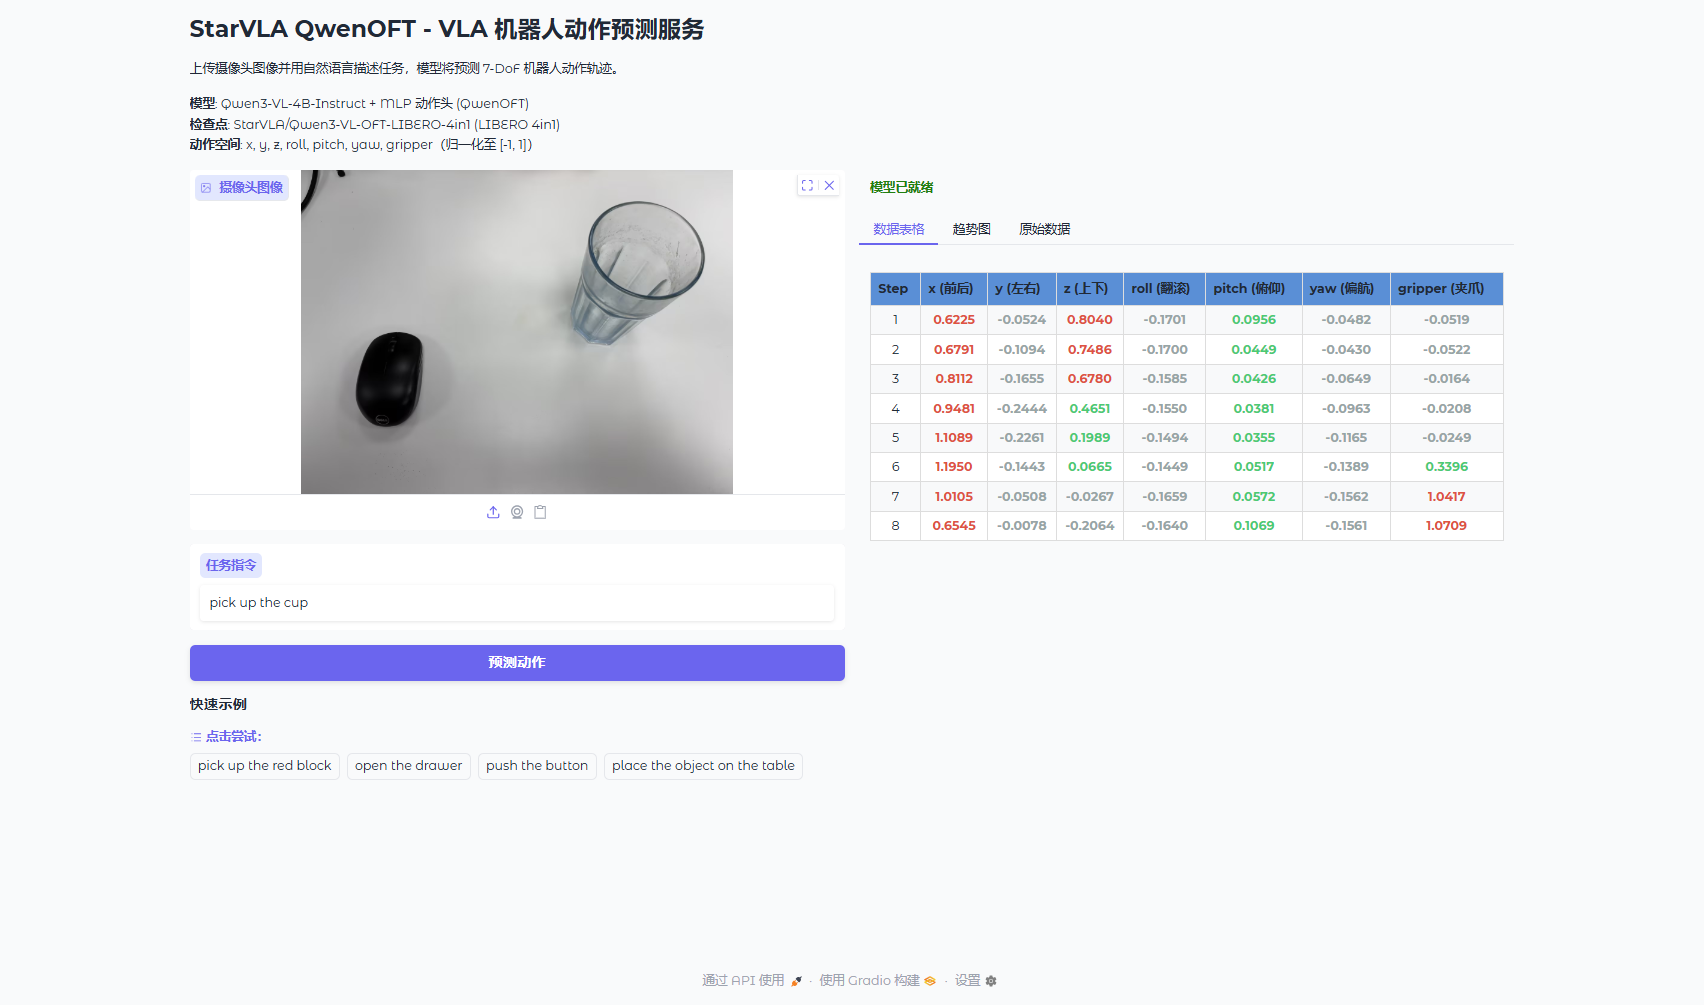

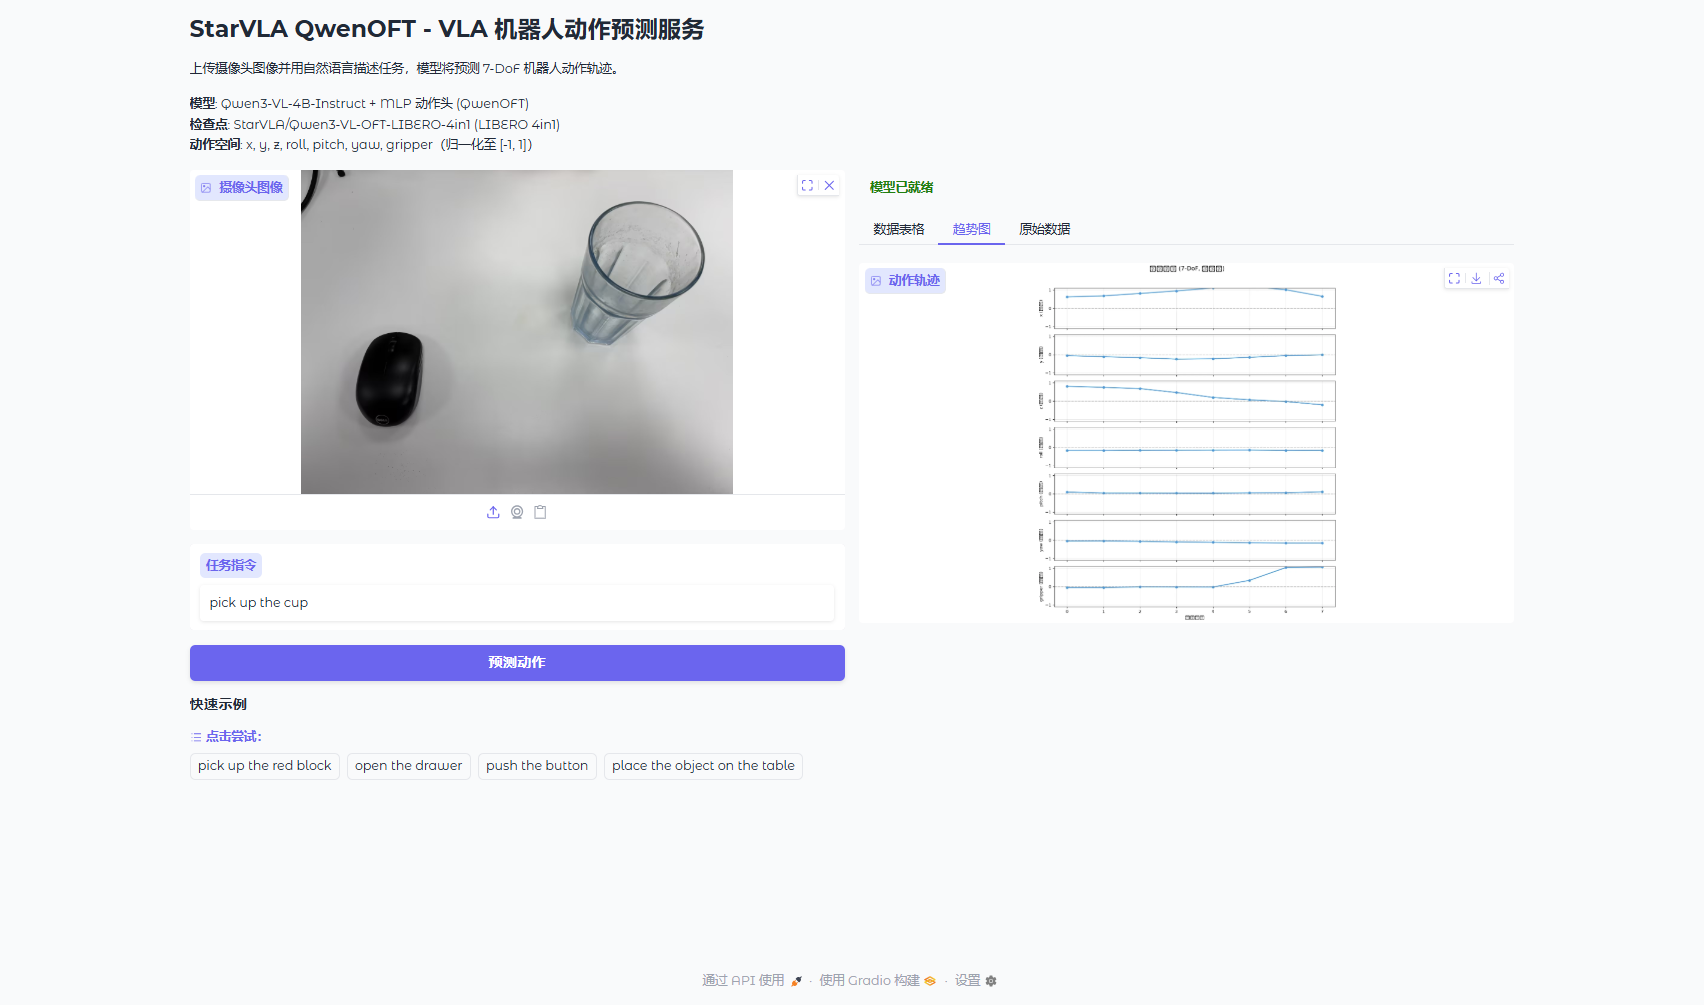

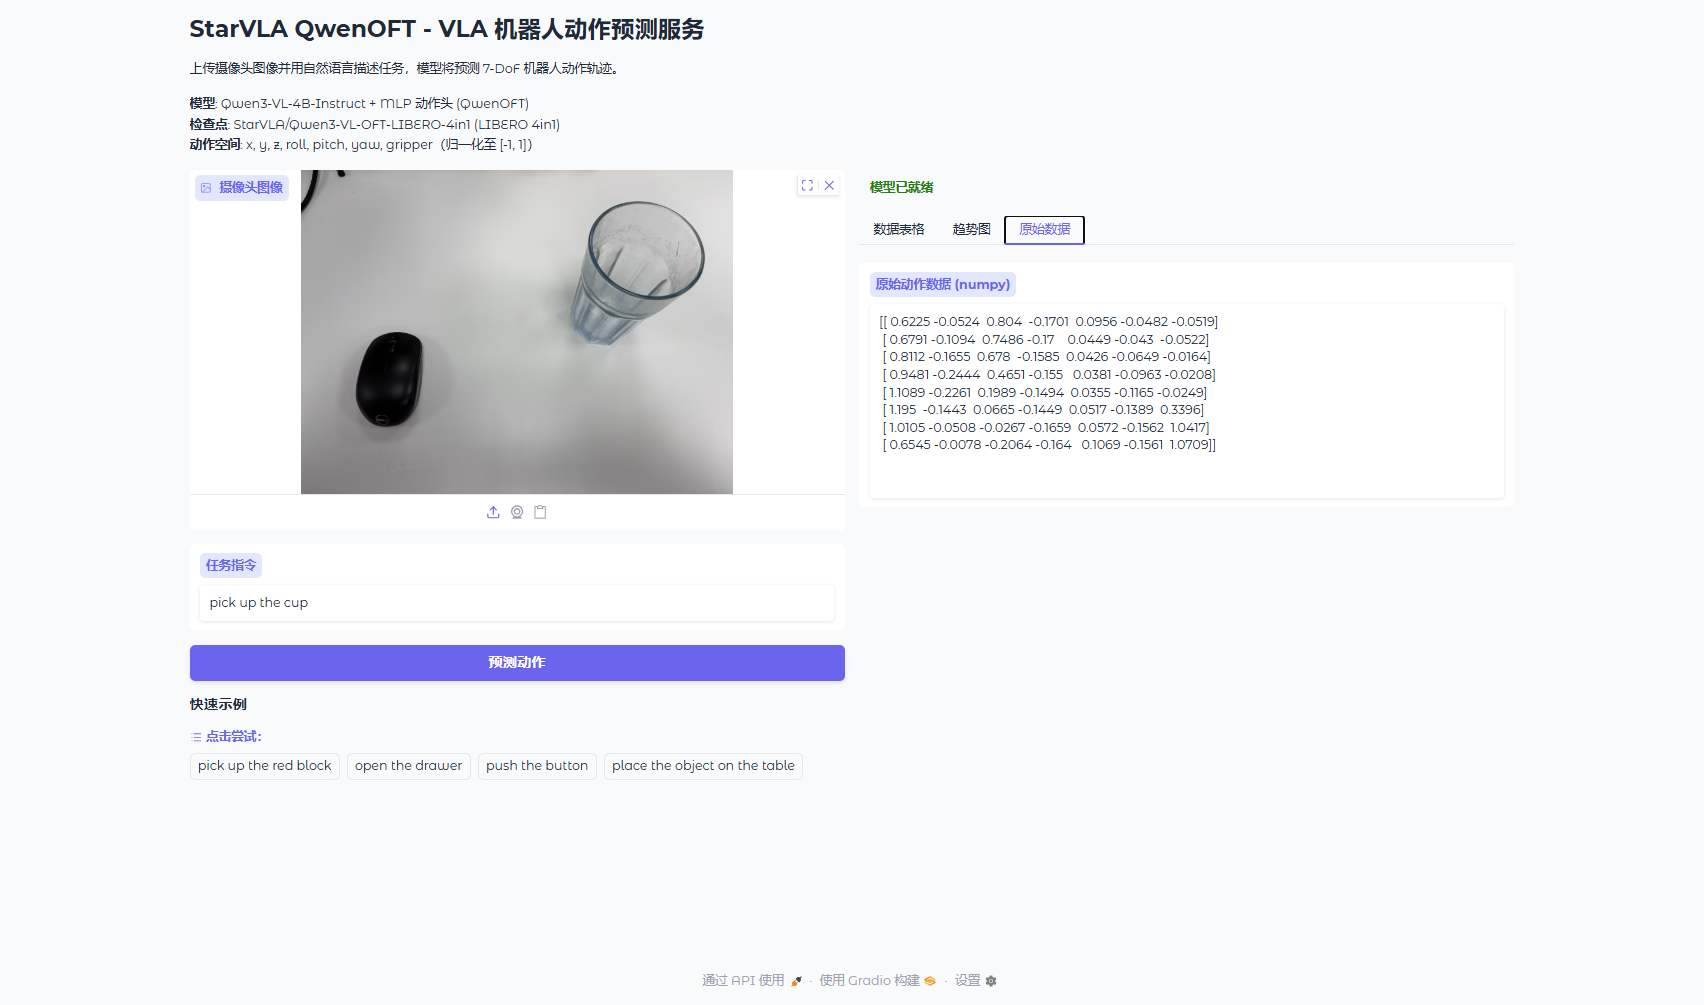

### 5.2 WebUI 操作步骤

1. 打开推理服务地址（端口 7860），进入 Gradio WebUI 界面
2. 等待页面顶部状态变为 **绿色「模型已就绪」**（首次加载约需 **2 分钟**）
3. 在左侧「摄像头图像」区域**上传测试图片**（上方任选一张）
4. 在「任务指令」框中输入对应的英文指令后点击「预测动作」
5. 查看右侧 3 个 Tab 的输出：
   - **数据表格**：每步的 7-DoF 归一化动作值
   - **趋势图**：动作随时间的折线图
   - **原始数据**：numpy 格式的完整动作数组

### 5.3 Python API 调用示例

推理服务支持通过 Gradio API 远程调用：


In [ ]:
import requests

# 推理服务地址
SERVER_URL = "https://your-service-url.com"

# 准备图片（base64 编码）
import base64
with open("robot_view.jpg", "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode()

# 调用 Gradio API
response = requests.post(
    f"{SERVER_URL}/api/predict",
    json={
        "data": [
            f"data:image/jpeg;base64,{img_b64}",  # image
            "pick up the red block",  # instruction
        ]
    },
)
result = response.json()
print("Actions:", result["data"][2])  # raw numpy text

### 5.3 直接 Python 调用模型

如果需要在开发环境中直接调用模型进行批量测试：


In [ ]:
import torch
import numpy as np
from PIL import Image
from pathlib import Path

VLM_PATH = "/gemini/pretrain/models/Qwen3-VL-4B-Instruct"
CKPT_PATH = "/gemini/pretrain/models/StarVLA/Qwen3-VL-OFT-LIBERO-4in1/checkpoints/steps_50000_pytorch_model.pt"

# 加载模型
from starVLA.model.framework.share_tools import read_mode_config, dict_to_namespace
from starVLA.model.framework.base_framework import build_framework

model_config, norm_stats = read_mode_config(CKPT_PATH)
model_config["framework"]["qwenvl"]["base_vlm"] = VLM_PATH
model_config["framework"]["qwenvl"]["attn_implementation"] = "flash_attention_2"
config = dict_to_namespace(model_config)
model = build_framework(config)

state_dict = torch.load(CKPT_PATH, map_location="cpu")
model.load_state_dict(state_dict, strict=True)
model.norm_stats = norm_stats
model = model.to("cuda", dtype=torch.bfloat16).eval()
print("Model loaded on GPU")

# ---- 使用 3 张测试图分别推理 ----
test_cases = [
    ("SPS.png",   "pick up the red block"),
    ("SPS2.png",  "open the drawer"),
    ("SPS3.png",  "place the object on the table"),
]

for img_name, instruction in test_cases:
    img = Image.open(img_name).convert("RGB")
    with torch.inference_mode():
        output = model.predict_action(examples=[{
            "image": [img],
            "lang": instruction,
        }])
    actions = output["normalized_actions"]
    print(f"[{img_name}] \"{instruction}\"")
    print(f"  Shape: {actions.shape}  (B={actions.shape[0]}, T={actions.shape[1]}, D={actions.shape[2]})")
    print(f"  Range: [{actions[0].min():.4f}, {actions[0].max():.4f}]")
    print()

## 六、测试结论

### 6.1 测试环境

| 项目 | 值 |
|------|------|
| **GPU** | P1.gpu.medium |
| **总显存** | 39.2 GB |
| **模型参数量** | 4B（VLM）+ 小 MLP 头 |
| **推理精度** | BF16 |
| **PyTorch** | 2.6.0+cu124 |
| **CUDA** | 12.4 |
| **transformers** | 5.12.1 |

### 6.2 核心结论

- **TTFT（端到端延迟）**：均值 **104.1ms**，P95 **120.1ms**，极低延迟
- **延迟稳定性**：P95/P50 = **1.17x**，非常稳定
- **峰值 VRAM**：**8.71GB**（22.2%），40GB GPU 绰绰有余
- **吞吐量（batch=1）**：**9.95 it/s**，每秒约 10 次推理
- **吞吐量（batch=4）**：**26.89 samples/s**，批量推理效率更高
- **动作分布**：7-DoF 均有响应（std > 0.001），模型对指令敏感
- **连续推理稳定性**：5 轮推理 VRAM 无泄漏
- **所有边缘情况通过**：空指令、特殊字符、长文本、灰度图

> 📋 详细的测试报告见 `/gemini/code/test_report.json`

## 七、注意事项

- **模型加载时间**：首次加载约 10-15 分钟（后台线程），状态框每 2 秒自动刷新
- **指令语言**：模型训练使用英文指令，建议用英文以获得最佳效果
- **图像要求**：建议上传真实场景图像，分辨率不限（内部自动缩放）
- **输出范围**：动作值归一化至 [-1, 1]，可通过 dataset_statistics.json 反归一化
- **Attention 实现**：当前使用 SDPA（flash_attn 未安装），短序列性能接近 Flash Attention
- **批量推理**：支持同时处理多个图像+指令对（batch ≤ 4 效果最佳）
- **完全离线**：所有模型文件从本地路径读取，无需联网
- **许可证**：MIT，可免费商用